In [46]:
%pip install matplotlib
%pip install seaborn
%pip install sentence-transformers==2.6.1

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [47]:
def get_abuse_focused_data(csv_path: str):
    import pandas as pd 
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    
    # Define keywords for drugs often associated with abuse or dependency
    high_abuse_potential_drugs = [
    "Acetaminophen / codeine", 
    "Acetaminophen / hydrocodone", 
    "Acetaminophen / oxycodone", 
    "Acetaminophen / tramadol", 
    "Adderall", 
    "Adderall XR", 
    "Adipex-P", 
    "Alprazolam", 
    "Alprazolam Intensol", 
    "Ambien", 
    "Ambien CR", 
    "Amphetamine",
    "Amphetamine / dextroamphetamine", 
    "Ativan", 
    "Belbuca", 
    "Benzphetamine", 
    "Buprenorphine",
    "Butabarbital", 
    "Butalbital", 
    "Butorphanol", 
    "Carisoprodol", 
    "Chlordiazepoxide",
    "Clonazepam", 
    "Clorazepate",
    "Codeine", 
    "Concerta",
    "Demerol", 
    "Desoxyn",
    "Dexedrine",
    "Dexmethylphenidate", 
    "Dextroamphetamine", 
    "Diazepam", 
    "Diethylpropion",
    "Dilaudid",
    "Dolophine", 
    "Duragesic", 
    "Embeda", 
    "Eszopiclone", 
    "Fentanyl", 
    "Fentora", 
    "Fiorinal",
    "Focalin", 
    "Hydrocodone",
    "Hydromorphone", 
    "Klonopin",
    "Lisdexamfetamine",
    "Lorcet", 
    "Lorazepam",
    "Lunesta",
    "Lyrica", 
    "Meperidine",
    "Methadone", 
    "Methamphetamine", 
    "Methylphenidate",
    "Modafinil",
    "Morphine", 
    "MS Contin", 
    "Nucynta", 
    "Opana", 
    "Oxybutynin",
    "Oxycodone",
    "OxyContin",
    "Oxymorphone",
    "Pentazocine",
    "Pentobarbital", 
    "Percocet", 
    "Phendimetrazine", 
    "Phentermine", 
    "Pregabalin", 
    "Provigil", 
    "Ritalin",
    "Roxicodone", 
    "Seconal",
    "Soma", 
    "Suboxone", 
    "Subutex", 
    "Tapentadol",
    "Temazepam",
    "Tramadol", 
    "Ultram",
    "Valium",
    "Vicodin",
    "Vyvanse", 
    "Xanax", 
    "Xyrem",
    "Zolpidem", 
]
    
    # Filter the dataframe
    # focused_df = df[df['drug_name'].str.contains(high_abuse_potential_drugs)]
    pattern = '|'.join(high_abuse_potential_drugs)
    focused_df = df[df['drug_name'].str.contains(pattern, case=False, na=False)]
    
    return focused_df

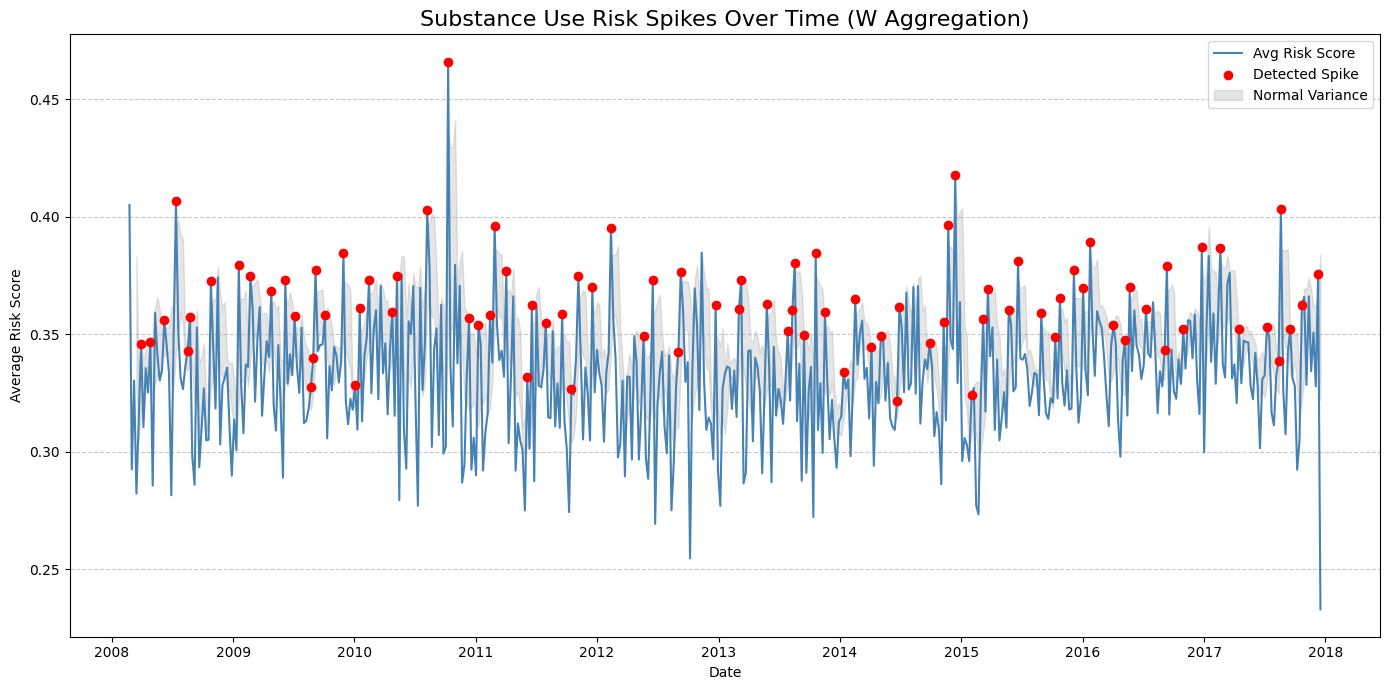

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_risk_spikes(csv_path: str, frequency: str = 'W'):
    """
    Input: Path to processed_signals.csv
    Output: A time-series plot highlighting statistical risk spikes
    """
    # 1. Load and Parse
    df = get_abuse_focused_data(csv_path=csv_path)
    df = df.sort_values('timestamp')

    # 2. Resample to calculate the Mean Risk Score per period
    # 'W' = Weekly, 'M' = Monthly
    temporal_df = df.resample(frequency, on='timestamp')['risk_score'].agg(['mean', 'count']).dropna()

    # 3. Define Spike Threshold (Mean + 2 Standard Deviations)
    rolling_mean = temporal_df['mean'].rolling(window=4).mean()
    rolling_std = temporal_df['mean'].rolling(window=4).std()
    threshold = rolling_mean + (1 * rolling_std)
    
    # Identify boolean mask for spikes
    spikes = temporal_df['mean'] > threshold

    # 4. Visualization
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=temporal_df, x=temporal_df.index, y='mean', label='Avg Risk Score', color='steelblue')
    
    # Highlight Spikes
    plt.scatter(temporal_df.index[spikes], temporal_df['mean'][spikes], color='red', label='Detected Spike', zorder=5)
    
    # Visual Polish
    plt.fill_between(temporal_df.index, rolling_mean, threshold, color='gray', alpha=0.2, label='Normal Variance')
    plt.title(f'Substance Use Risk Spikes Over Time ({frequency} Aggregation)', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Average Risk Score')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('../visualizations/cumulative_spikes_over_time.png')
    plt.show()

    return temporal_df[spikes]

# Execute
high_risk_periods = plot_risk_spikes("../data/processed_signals.csv", frequency='W')

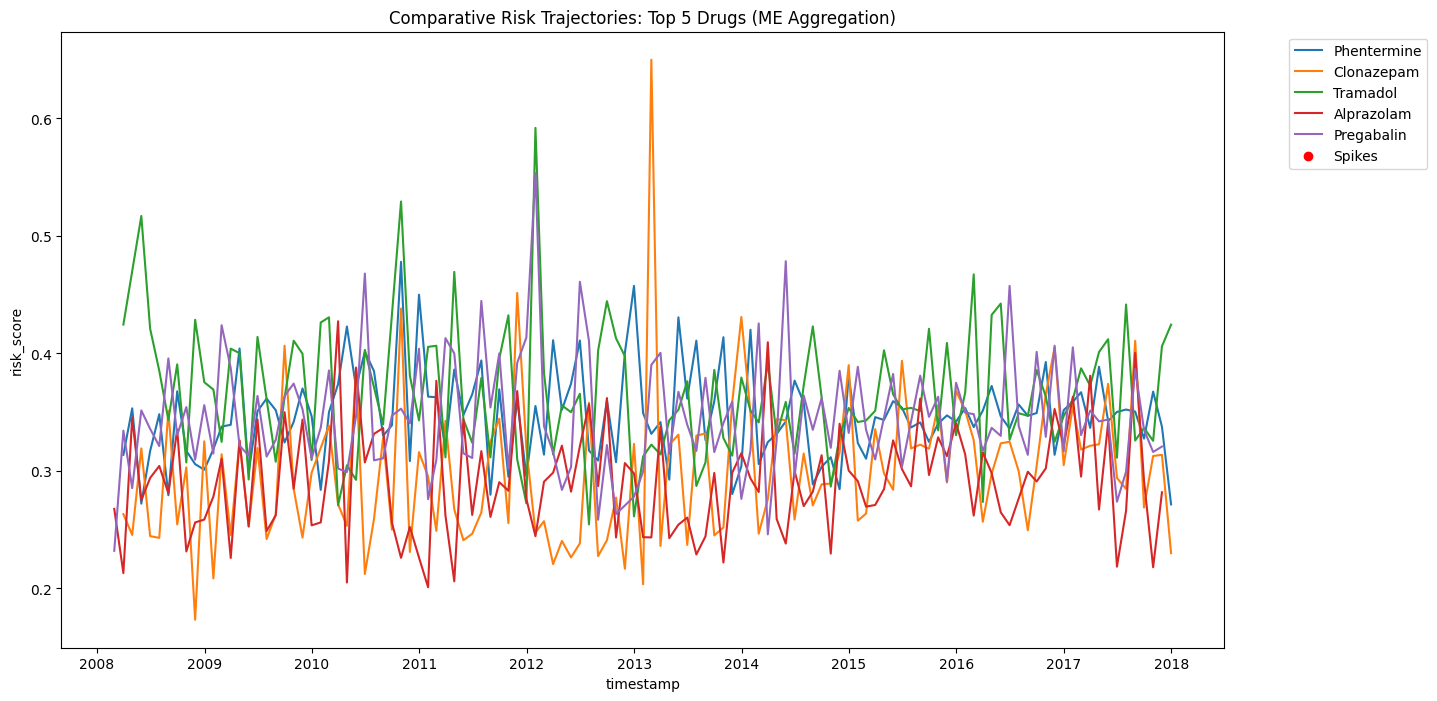

,timestamp,risk_score,drug_name,rolling_avg,rolling_std,is_spike
0,2008-03-31,0.313667,Phentermine,0.313667,NaN,False
1,2008-04-30,0.353250,Phentermine,0.333458,0.027990,False
2,2008-05-31,0.272143,Phentermine,0.313020,0.040557,False
3,2008-06-30,0.317000,Phentermine,0.314015,0.033175,False
4,2008-07-31,0.348286,Phentermine,0.322670,0.037311,False
...,...,...,...,...,...,...
585,2017-07-31,0.299333,Pregabalin,0.314727,0.034187,False
586,2017-08-31,0.386600,Pregabalin,0.325846,0.049755,False
587,2017-09-30,0.335000,Pregabalin,0.323671,0.048897,False
588,2017-10-31,0.316143,Pregabalin,0.334269,0.037807,False


In [49]:
def analyze_top_5_drug_spikes(csv_path: str, frequency: str = 'M'):
    # 1. Load and immediately fix the index
    df = get_abuse_focused_data(csv_path=csv_path)
    
    # CRITICAL: Drop duplicates and reset index to ensure alignment
    df = df.drop_duplicates(subset=['review_id'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # 2. Identify Top 5
    top_5_drugs = df['drug_name'].value_counts().nlargest(5).index.tolist()
    
    # 3. Use a more stable grouping method
    # We use a list to collect results to avoid internal 'resample' indexing bugs
    drug_series = []
    
    for drug in top_5_drugs:
        drug_df = df[df['drug_name'] == drug].copy()
        
        # Resample and calculate mean
        resampled = (
            drug_df.set_index('timestamp')['risk_score']
            .resample(frequency)
            .mean()
            .reset_index()
        )
        resampled['drug_name'] = drug
        
        # Calculate the spike threshold locally to the drug to prevent offset errors
        # This keeps the 'spikes' mask the same length as the 'resampled' dataframe
        resampled['rolling_avg'] = resampled['risk_score'].rolling(window=4, min_periods=1).mean()
        resampled['rolling_std'] = resampled['risk_score'].rolling(window=4, min_periods=1).std()
        resampled['is_spike'] = resampled['risk_score'] > (resampled['rolling_avg'] + 2 * resampled['rolling_std'])
        
        drug_series.append(resampled)
    
    # Combine back into one clean plotting dataframe
    final_plot_df = pd.concat(drug_series).reset_index(drop=True)
    
    # 4. Plotting
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=final_plot_df, x='timestamp', y='risk_score', hue='drug_name')
    
    # Add spikes as red dots only where 'is_spike' is True
    spike_data = final_plot_df[final_plot_df['is_spike'] == True]
    plt.scatter(spike_data['timestamp'], spike_data['risk_score'], color='red', label='Spikes', zorder=5)
    
    plt.title(f'Comparative Risk Trajectories: Top 5 Drugs ({frequency} Aggregation)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig('../visualizations/rrisk_trajectories.png')
    plt.show()

    return final_plot_df

# Execute
analyze_top_5_drug_spikes("../data/processed_signals.csv", frequency='ME')

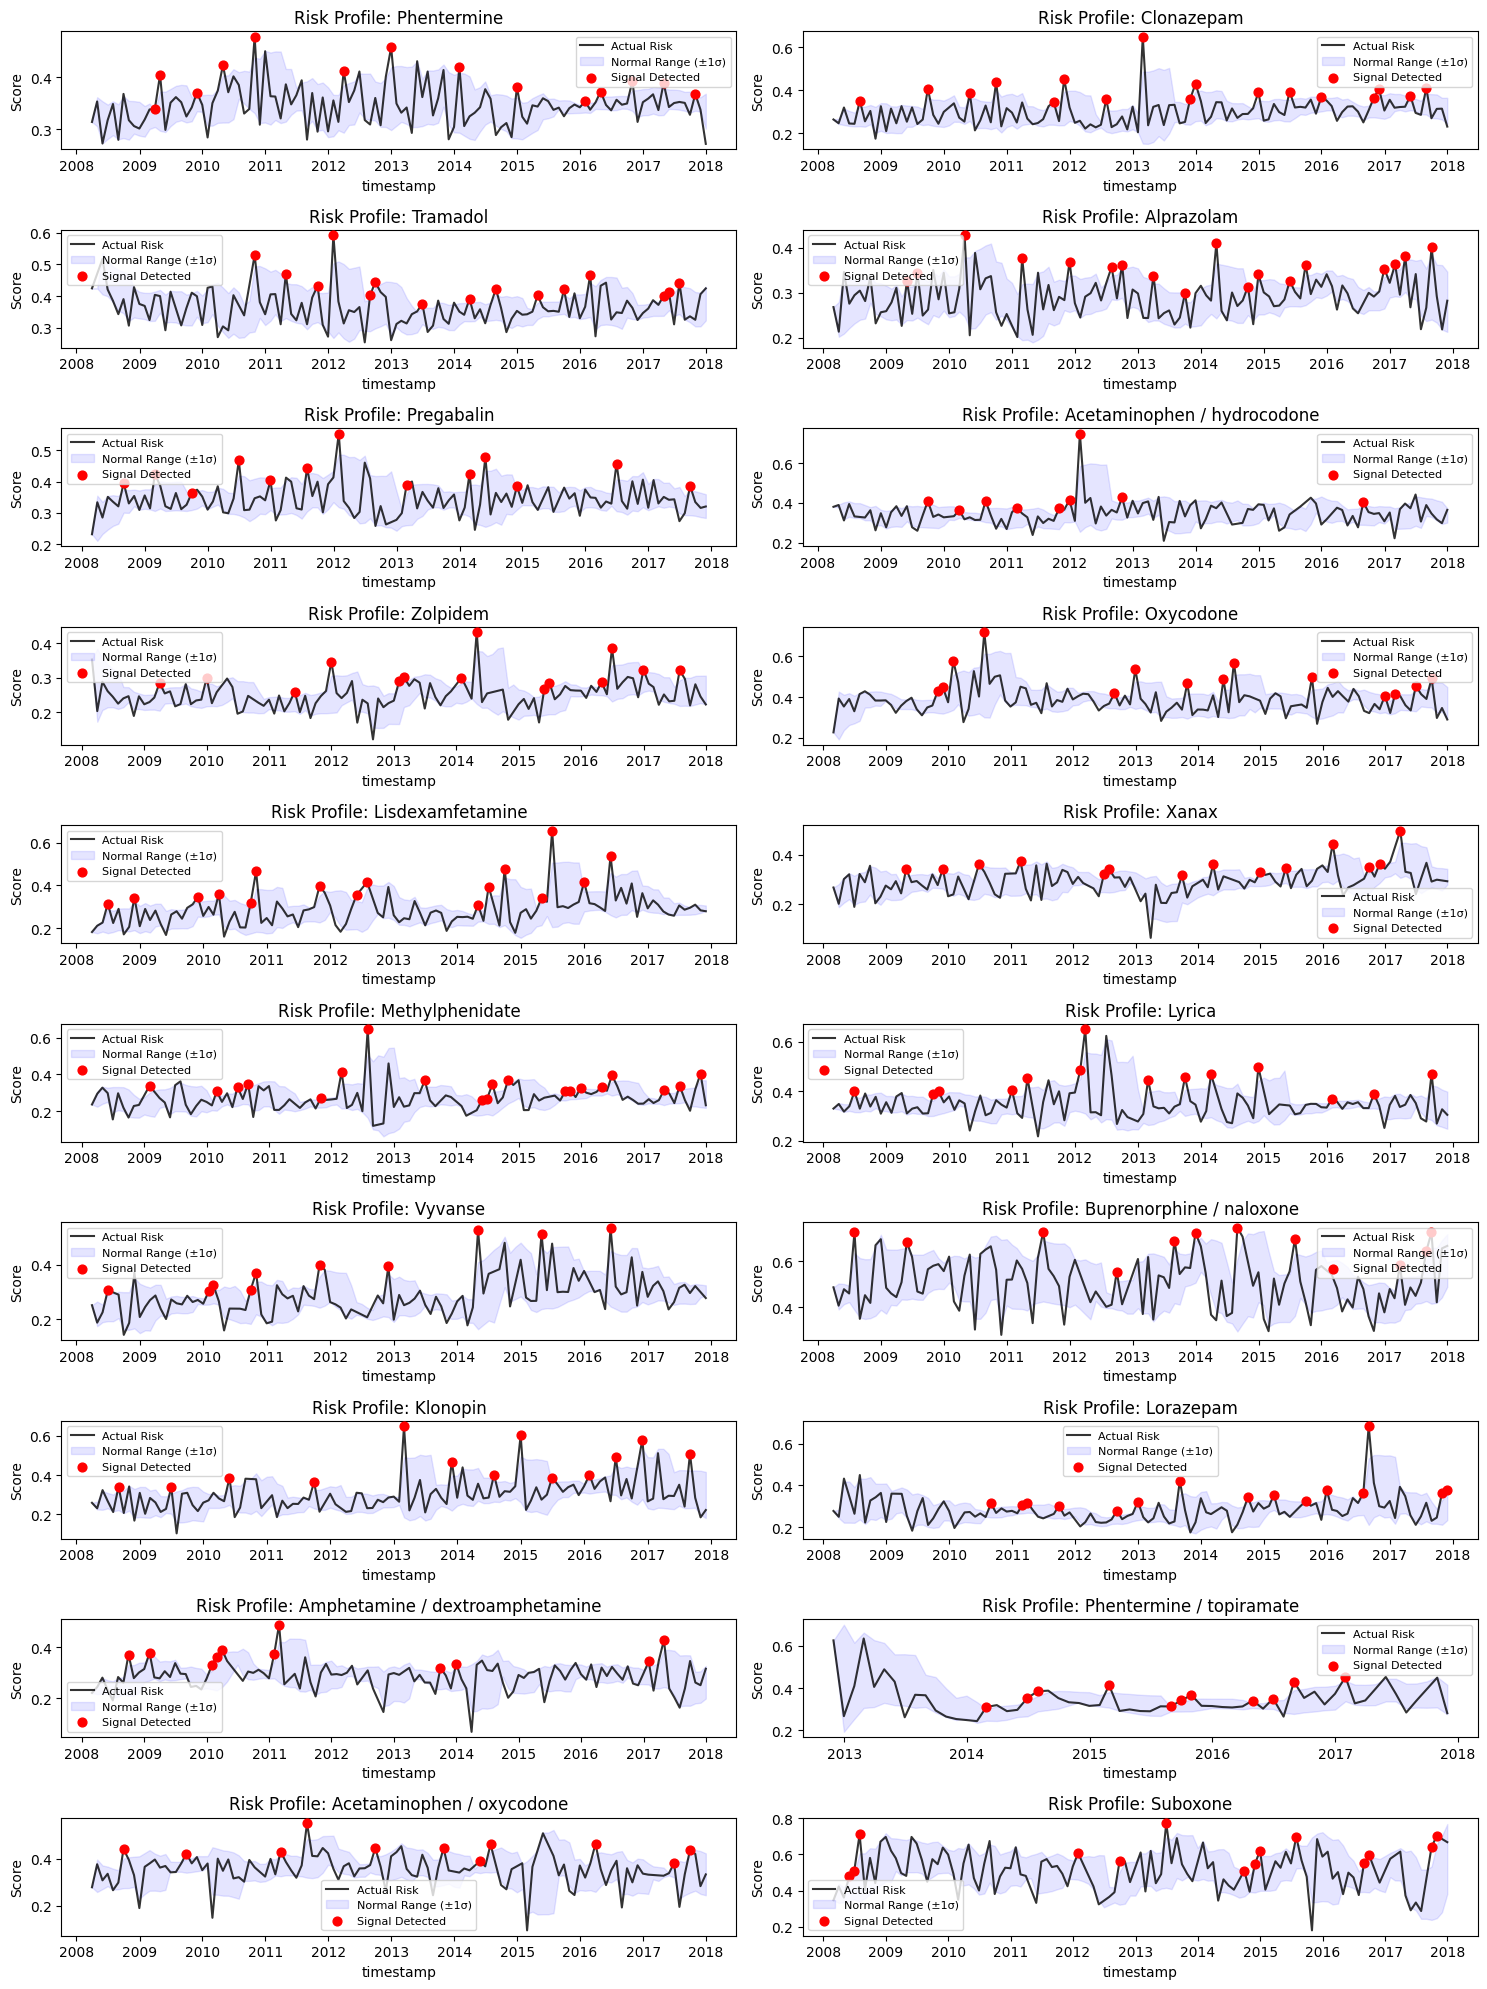

In [50]:
def analyze_with_high_sensitivity(csv_path: str, sensitivity=1.2):
    df = get_abuse_focused_data(csv_path=csv_path)
    df = df.drop_duplicates(subset=['review_id']).sort_values('timestamp')
    
    # Analyze top 5
    top = df['drug_name'].value_counts().nlargest(20).index.tolist()
    
    plt.figure(figsize=(15, int(len(top))))
    
    for i, drug in enumerate(top, 1):
        plt.subplot(int(len(top)/2), 2, i)
        
        # Resample
        data = df[df['drug_name'] == drug].set_index('timestamp')['risk_score'].resample('ME').mean().reset_index()
        
        # Math: Rolling window of 6 months for a smoother baseline
        data['mu'] = data['risk_score'].rolling(window=6, min_periods=1).mean()
        data['std'] = data['risk_score'].rolling(window=6, min_periods=1).std().fillna(0)
        
        # New Threshold (Adjustable sensitivity)
        data['threshold'] = data['mu'] + (sensitivity * data['std'])
        data['is_spike'] = (data['risk_score'] > data['threshold']) & (data['std'] > 0)
        
        # Plotting
        # 1. The actual risk line
        sns.lineplot(data=data, x='timestamp', y='risk_score', label='Actual Risk', color='black', alpha=0.8)
        
        # 2. The "Normal Band" (Center it around the mean)
        plt.fill_between(data['timestamp'], 
                         data['mu'] - data['std'], 
                         data['mu'] + data['std'], 
                         color='blue', alpha=0.1, label='Normal Range (±1σ)')
        
        # 3. The Spikes
        spikes = data[data['is_spike']]
        if not spikes.empty:
            plt.scatter(spikes['timestamp'], spikes['risk_score'], color='red', s=40, label='Signal Detected', zorder=5)
            
        plt.title(f"Risk Profile: {drug}")
        plt.ylabel("Score")
        plt.legend(prop={'size': 8})

    plt.tight_layout()
    plt.savefig('../visualizations/top_drugs_spikes.png')
    plt.show()

# Try running this with 1.2 sensitivity
analyze_with_high_sensitivity("../data/processed_signals.csv", sensitivity=1.2)

In [51]:
kmeans_model=None
tfidf_model=None
train_summary_df=None

1. Loading and filtering data...
Clustering 1612 high-risk reviews into 4 topics...
Extracting narrative keywords...


C:\Users\fne\AppData\Local\Temp\ipykernel_556\568186719.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=analysis_df, x='cluster_id', palette='viridis')


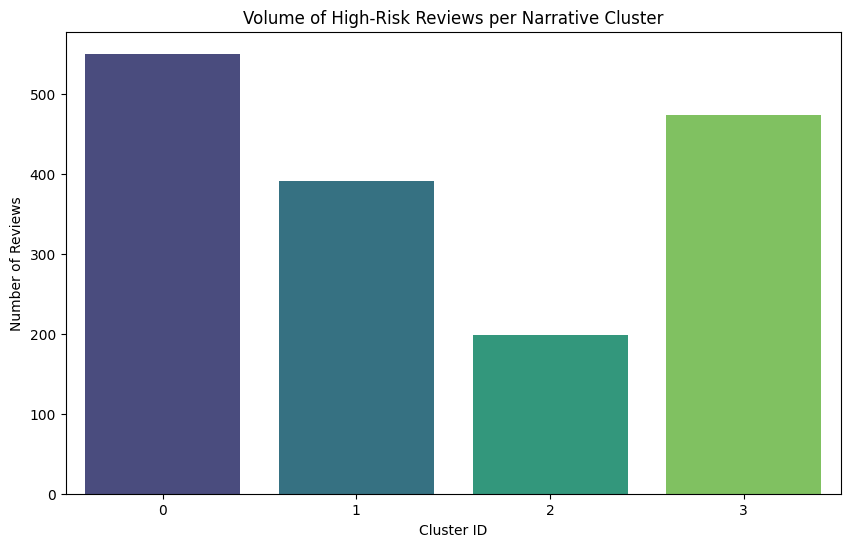

   Cluster  Size                           Top Keywords
0        0   550  039, anxiety, withdrawal, day, taking
1        1   391    039, day, withdrawal, years, taking
2        2   198   039, weight, lost, cravings, started
3        3   473   039, suboxone, day, methadone, years


In [52]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def discover_narrative_clusters(csv_path: str, embeddings_path: str, num_clusters: int = 5):
    """
    Input: Filtered CSV and the .npz embeddings file.
    Output: A dataframe of clusters with their defining keywords.
    """
    print("1. Loading and filtering data...")
    # Load tabular data
    df = get_abuse_focused_data(csv_path)
    
    # Filter for High-Abuse Drugs AND High Risk (e.g., distress flag or risk score > threshold)
    # Adjust the threshold based on your sensitivity testing from earlier
    high_risk_df = df[(df['risk_score'] > 0.6) | (df['emotional_tone'] == 'distress')].copy()
    
    # Load embeddings
    npz_file = np.load(embeddings_path)
    saved_ids = npz_file['review_ids']
    saved_embeddings = npz_file['embeddings']
    
    # Map embeddings to the filtered dataframe
    # We create a dictionary for fast lookup
    embed_dict = {rev_id: vec for rev_id, vec in zip(saved_ids, saved_embeddings)}
    
    # Filter out rows that don't have embeddings (safety check)
    valid_ids = [rid for rid in high_risk_df['review_id'] if rid in embed_dict]
    analysis_df = high_risk_df[high_risk_df['review_id'].isin(valid_ids)].copy()
    
    # Load your original raw data to get the text back
    raw_df = pd.read_csv("../data/raw/drugsComTrain_raw.csv", usecols=['uniqueID', 'review'])

    # Merge the text into your analysis dataframe
    analysis_df = analysis_df.merge(raw_df, left_on='review_id', right_on='uniqueID', how='left')

    # Now the column 'review' exists for the loop
    # Build the final embedding matrix for clustering
    matrix = np.array([embed_dict[rid] for rid in analysis_df['review_id']])
    
    print(f"Clustering {len(matrix)} high-risk reviews into {num_clusters} topics...")
    
    # 2. Perform K-Means Clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
    analysis_df['cluster_id'] = kmeans.fit_predict(matrix)
    
    global kmeans_model
    kmeans_model=kmeans
    
    # 3. Extract Keywords using TF-IDF
    print("Extracting narrative keywords...")
    tfidf = TfidfVectorizer(max_df=0.8, min_df=2, stop_words='english')

    global tfidf_model
    tfidf_model = tfidf
    
    cluster_summaries = []
    
    for cluster_num in range(num_clusters):
        cluster_text = analysis_df[analysis_df['cluster_id'] == cluster_num]['review'] # Use clean_text if available in CSV
        # Select the text using the validated column name
    
        if cluster_text.empty:
            continue
        
        # Fit TF-IDF on this cluster's text
        tfidf_matrix = tfidf.fit_transform(cluster_text.fillna(''))
        feature_names = np.array(tfidf.get_feature_names_out())
        
        # Get top 5 words by average TF-IDF score
        avg_scores = tfidf_matrix.mean(axis=0).A1
        top_indices = avg_scores.argsort()[-5:][::-1]
        top_words = feature_names[top_indices]
        
        cluster_summaries.append({
            'Cluster': cluster_num,
            'Size': len(cluster_text),
            'Top Keywords': ", ".join(top_words)
        })
        
    summary_df = pd.DataFrame(cluster_summaries)
    
    # 4. Optional: Visualize cluster sizes
    plt.figure(figsize=(10, 6))
    sns.countplot(data=analysis_df, x='cluster_id', palette='viridis')
    plt.title('Volume of High-Risk Reviews per Narrative Cluster')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Reviews')
    plt.savefig('../visualizations/cluster_counts.png')
    plt.show()
    
    return summary_df, analysis_df

# Execute
summaries, clustered_data = discover_narrative_clusters("../data/processed_signals.csv", "../data/embeddings.npz", num_clusters=4)
print(summaries)

train_summary_df = summaries

C:\Users\fne\AppData\Local\Temp\ipykernel_556\3220730716.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  clustered_df.groupby(['cluster_id', pd.Grouper(key='timestamp', freq=frequency)])


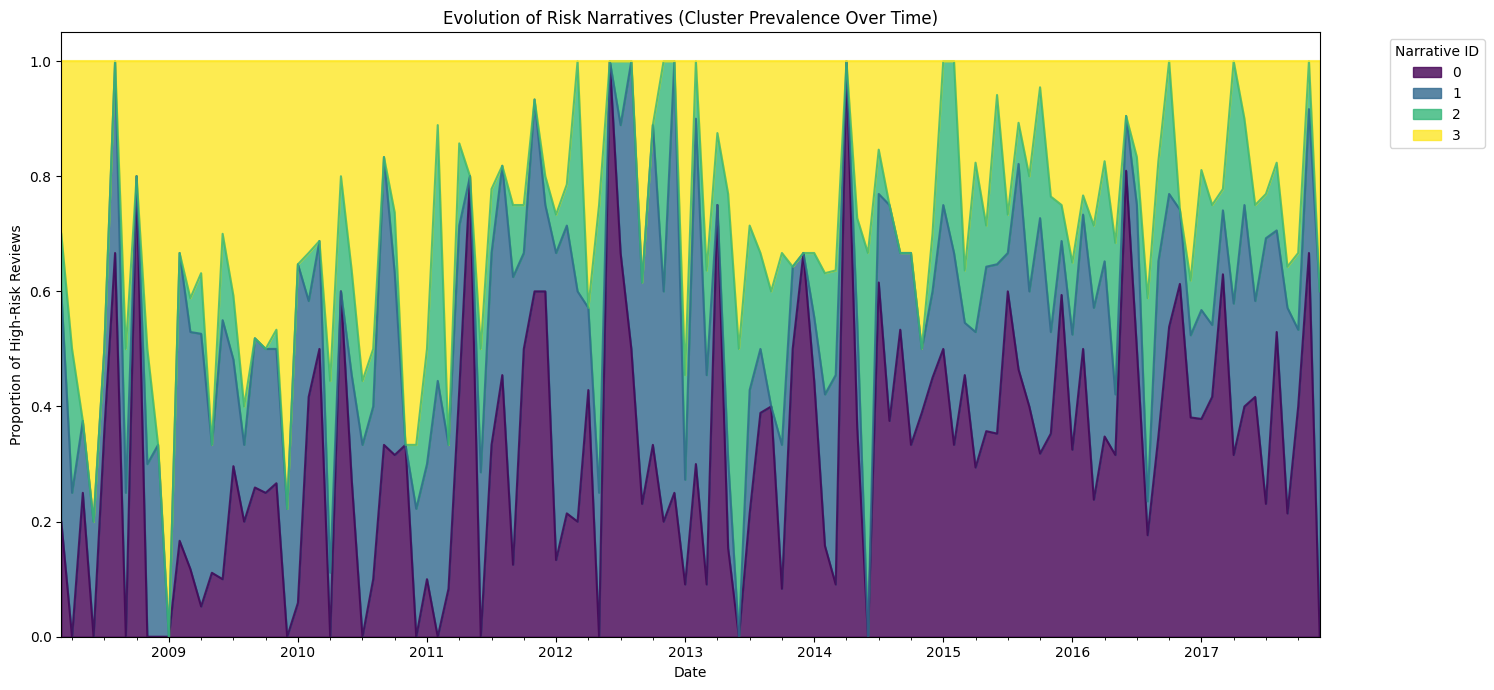

cluster_id,0,1,2,3
timestamp,,,,
2008-03-31,2.0,4.0,1.0,3.0
2008-04-30,0.0,1.0,1.0,2.0
2008-05-31,2.0,1.0,0.0,5.0
2008-06-30,0.0,1.0,0.0,4.0
2008-07-31,5.0,2.0,0.0,7.0
...,...,...,...,...
2017-08-31,9.0,3.0,2.0,3.0
2017-09-30,3.0,5.0,1.0,5.0
2017-10-31,6.0,2.0,2.0,5.0


In [53]:
def evaluate_cluster_temporal_distribution(clustered_df, frequency='M'):
    """
    Input: The analysis_df from the previous clustering step.
    Output: A stacked area chart showing how narratives shift over time.
    """
    # 1. Resample to count cluster occurrences over time
    temporal_clusters = (
        clustered_df.groupby(['cluster_id', pd.Grouper(key='timestamp', freq=frequency)])
        .size()
        .unstack(level=0)
        .fillna(0)
    )

    # 2. Normalize to show percentage (Relative Prevalence)
    # This helps see if a narrative is "taking over" the conversation
    temporal_percentage = temporal_clusters.div(temporal_clusters.sum(axis=1), axis=0)

    # 3. Plotting
    plt.figure(figsize=(15, 7))
    temporal_percentage.plot(kind='area', stacked=True, colormap='viridis', alpha=0.8, ax=plt.gca())
    
    plt.title("Evolution of Risk Narratives (Cluster Prevalence Over Time)")
    plt.ylabel("Proportion of High-Risk Reviews")
    plt.xlabel("Date")
    plt.legend(title="Narrative ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('../visualizations/stacked_area_map.png')
    plt.show()

    return temporal_clusters

evaluate_cluster_temporal_distribution(clustered_df=clustered_data)

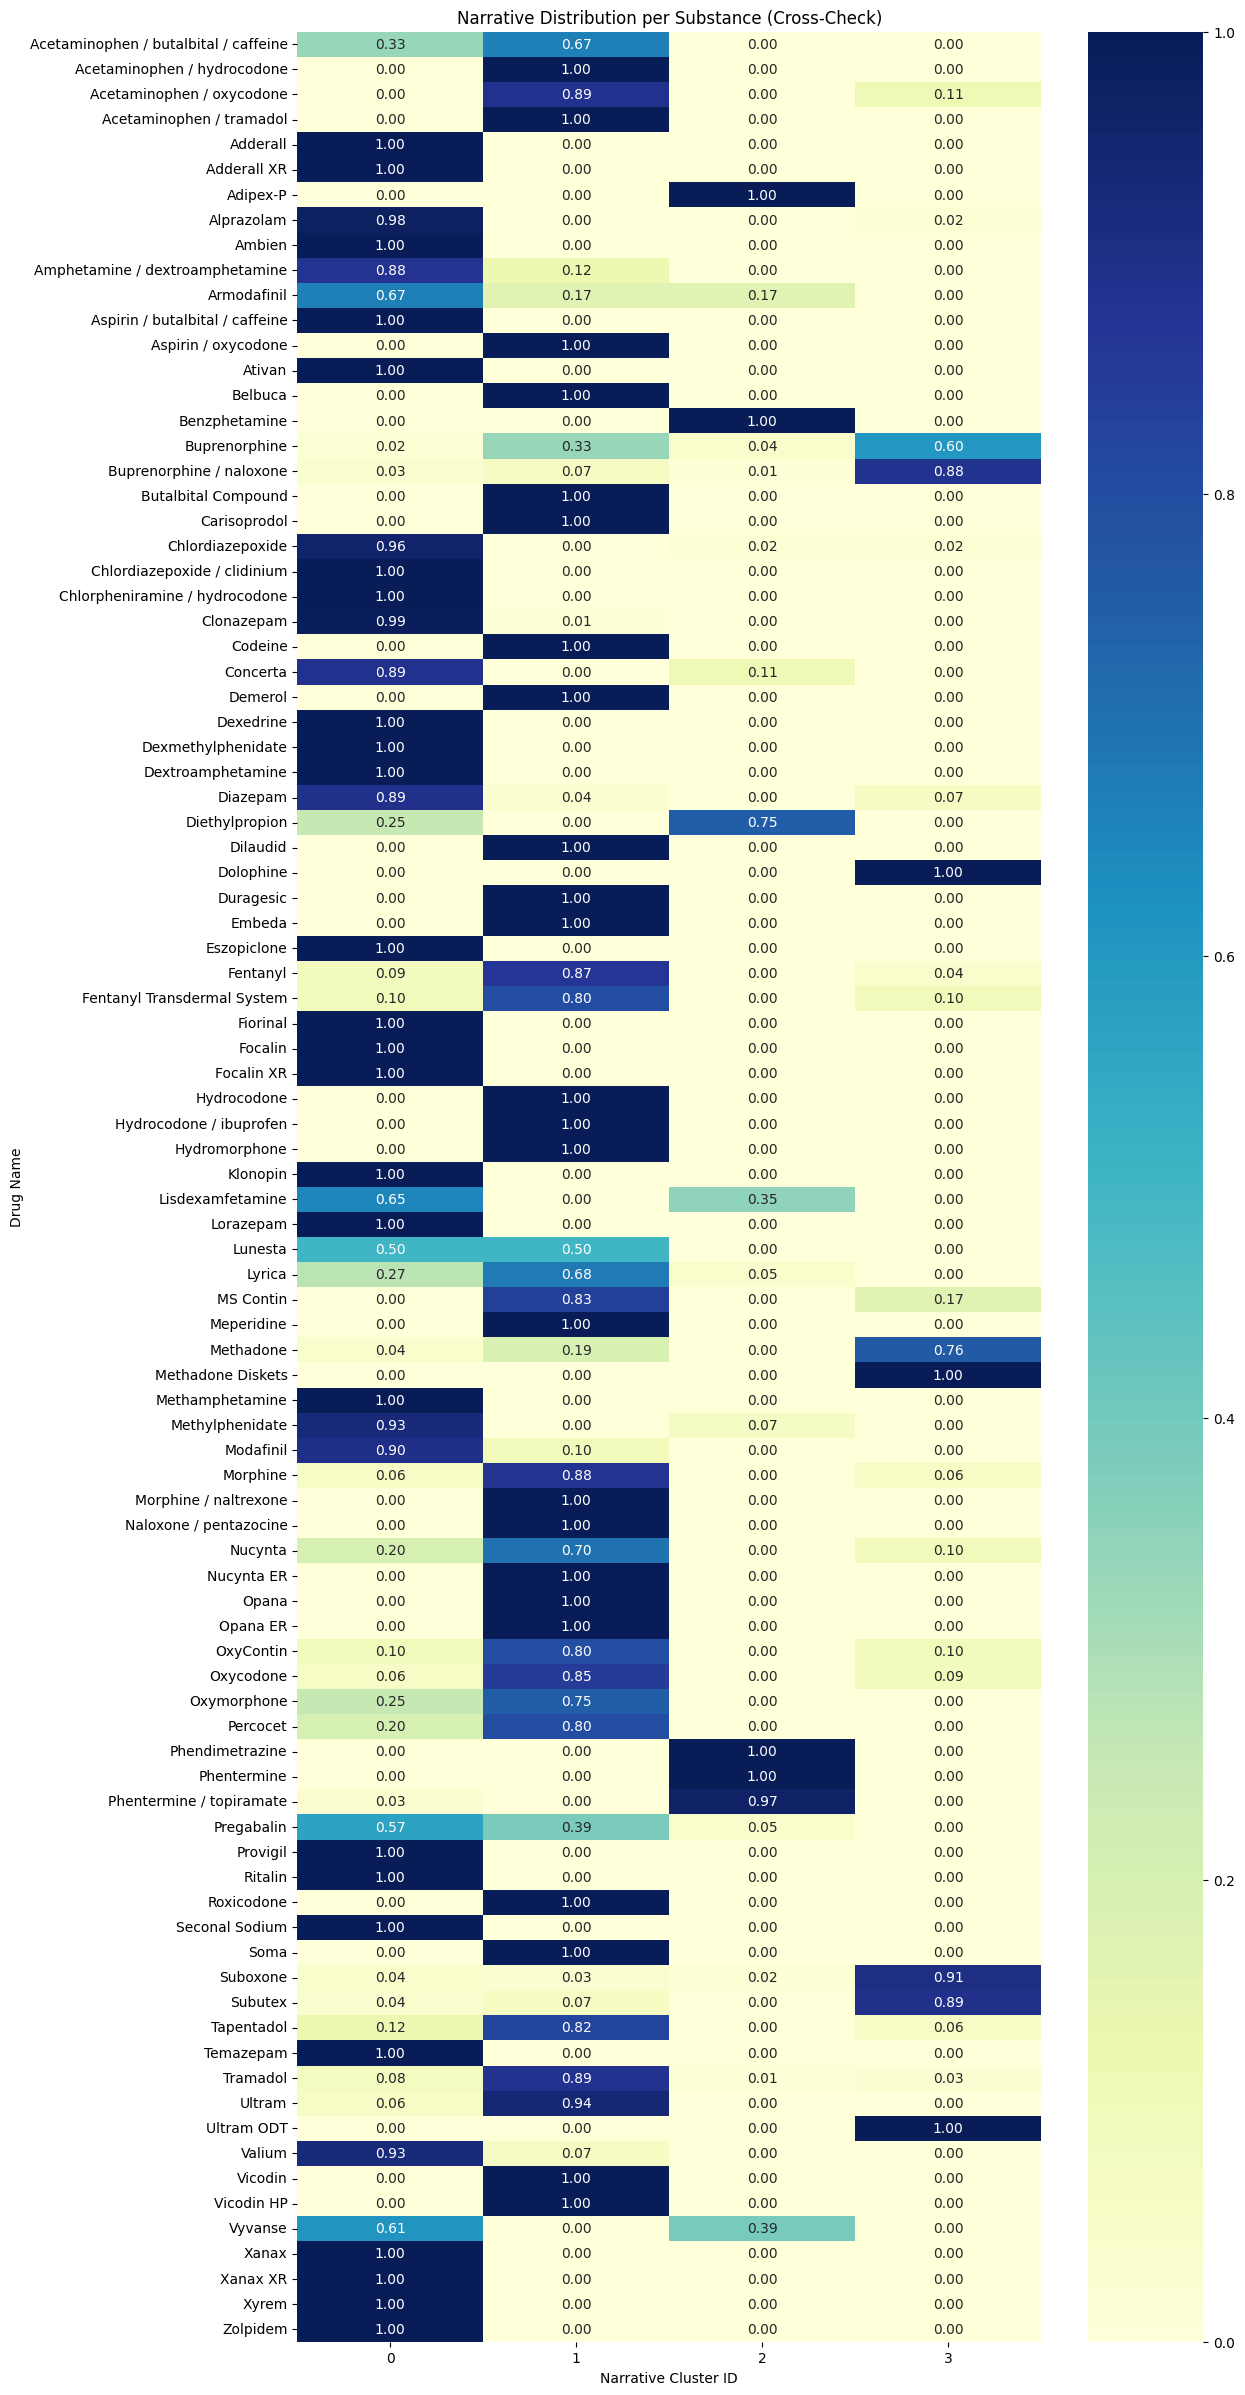

In [54]:
def plot_drug_narrative_heatmap(clustered_df):
    """
    Cross-checks which drugs are most associated with which narratives.
    """
    # Create a contingency table
    cross_tab = pd.crosstab(clustered_df['drug_name'], clustered_df['cluster_id'])
    
    # Normalize by row (Drug) to see the distribution of narratives per drug
    cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0)
    cross_tab_norm.to_csv('../data/heatmap.csv', index=True)
    plt.figure(figsize=(12, 30))
    sns.heatmap(cross_tab_norm, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Narrative Distribution per Substance (Cross-Check)")
    plt.xlabel("Narrative Cluster ID")
    plt.ylabel("Drug Name")
    plt.savefig('../visualizations/heatmap.png')
    plt.show()

plot_drug_narrative_heatmap(clustered_data)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer

def test_cluster_generalization(test_csv_path, raw_csv_path, trained_kmeans, trained_tfidf, train_summaries):
    """
    Validates if the narratives discovered in the training set hold true for unseen data.
    """
    print("1. Loading and encoding test data...")
    # 1. Load results AND raw text
    test_df = pd.read_csv(test_csv_path) # The results (scores)
    raw_df = pd.read_csv(raw_csv_path)   # The raw data (text)

    # 2. Join them to get the 'review' column back
    # 'uniqueID' is the alias for review_id in the raw Kaggle file
    test_df = test_df.merge(raw_df[['uniqueID', 'review']], left_on='review_id', right_on='uniqueID')
    # test_df = pd.read_csv(test_csv_path)
    
    # Apply the same high-risk / SoI filter you used for training
    high_risk_test = test_df[(test_df['risk_score'] > 0.6) | (test_df['emotional_tone'] == 'distress')].copy()

    # Generate embeddings for the test set (using the same model from Phase 1)
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    
    print('Encoding...')
    test_embeddings = embedder.encode(high_risk_test['review'].tolist(), convert_to_numpy=True).astype('float64')
    test_embeddings = np.array(test_embeddings).astype('float64')

    # 2. Debug print to be 100% sure
    print(f"Model expects 32-bit. Data is currently: {test_embeddings.dtype}")
    print("2. Predicting cluster assignments for unseen data...")
    # CRITICAL: Use .predict(), NOT .fit_predict()
    high_risk_test['cluster_id'] = trained_kmeans.predict(test_embeddings)
    
    print("3. Evaluating Narrative Consistency...")
    test_summaries = []
    
    for cluster_num in range(trained_kmeans.n_clusters):
        # Get test reviews assigned to this cluster
        cluster_text = high_risk_test[high_risk_test['cluster_id'] == cluster_num]['review']
        
        if len(cluster_text) == 0:
            continue
            
        # CRITICAL: Use .transform(), NOT .fit_transform() to use the training vocabulary
        tfidf_matrix = trained_tfidf.transform(cluster_text.fillna(''))
        feature_names = np.array(trained_tfidf.get_feature_names_out())
        
        # Extract top words for the test set
        avg_scores = tfidf_matrix.mean(axis=0).A1
        top_indices = avg_scores.argsort()[-5:][::-1]
        top_words = feature_names[top_indices]
        
        test_summaries.append({
            'Cluster': cluster_num,
            'Test Size': len(cluster_text),
            'Test Keywords': ", ".join(top_words)
        })
    
    test_summary_df = pd.DataFrame(test_summaries)
    
    # Merge with training summaries for side-by-side comparison
    comparison_df = pd.merge(train_summaries, test_summary_df, on='Cluster', how='left')
    
    # 4. Calculate Test Silhouette Score
    # test_score = silhouette_score(test_embeddings, high_risk_test['cluster_id'])
    # print(f"\nTest Set Silhouette Score: {test_score:.3f}")
    
    # 5. Visual Comparison of Distributions
    # Check if the proportion of reviews in each cluster is roughly similar
    # (Code for side-by-side bar chart omitted for brevity, but recommended)
    
    return comparison_df, high_risk_test

# Example execution (assuming models are passed in from your previous script):
comparison, tested_data = test_cluster_generalization("../data/processed_signals.csv", "../data/raw/drugsComTrain_raw.csv", kmeans_model, tfidf_model, train_summary_df)
print(comparison[['Cluster', 'Top Keywords', 'Test Keywords']])


1. Loading and encoding test data...


ValueError: Backend should be defined in the BACKENDS_MAPPING. Offending backend: tf

In [ ]:
comparison.to_csv('../visualizations/cluster_comparison.csv', index=True)
comparison

,Cluster,Size,Top Keywords,Test Size,Test Keywords
0,0,550,"039, anxiety, withdrawal, day, taking",3979,"039, suicidal, anxiety, depression, thoughts"
1,1,391,"039, day, withdrawal, years, taking",1220,"pain, 039, effects, months, withdrawal"
2,2,198,"039, weight, lost, cravings, started",1871,"039, weight, cravings, eat, lost"
3,3,473,"039, suboxone, day, methadone, years",708,"039, suboxone, day, years, life"
